<a href="https://colab.research.google.com/github/R3beAM/Proyecto-Final-Integracion/blob/second/Evaluacion_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Descripción del dataset original**

In [ ]:
import pandas as pd
import numpy as np

import nltk
from nltk.corpus import stopwords

import re
import string

In [ ]:
# Ruta al archivo (ajusta el nombre del archivo)
file_path = "/content/Amazon_Consumer_Review.csv"

# =========================
# 1. Cargar dataset
# =========================

df = pd.read_csv("Amazon_Consumer_Review.csv")

print("DESCRIPCIÓN GENERAL DEL DATASET")
print("-" * 50)
print("Filas y columnas:", df.shape)
print("Cantidad de filas:", df.shape[0])
print("Cantidad de columnas:", df.shape[1])

print("\nColumnas del dataset:")
print(df.columns.tolist())

print("\nPrimeras filas:")
display(df.head())

print("\nInformación general:")
df.info()

DESCRIPCIÓN GENERAL DEL DATASET
--------------------------------------------------
Filas y columnas: (28332, 24)
Cantidad de filas: 28332
Cantidad de columnas: 24

Columnas del dataset:
['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand', 'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer', 'manufacturerNumber', 'reviews.date', 'reviews.dateSeen', 'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs']

Primeras filas:


,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28332 entries, 0 to 28331
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   28332 non-null  object 
 1   dateAdded            28332 non-null  object 
 2   dateUpdated          28332 non-null  object 
 3   name                 28332 non-null  object 
 4   asins                28332 non-null  object 
 5   brand                28332 non-null  object 
 6   categories           28332 non-null  object 
 7   primaryCategories    28332 non-null  object 
 8   imageURLs            28332 non-null  object 
 9   keys                 28332 non-null  object 
 10  manufacturer         28332 non-null  object 
 11  manufacturerNumber   28332 non-null  object 
 12  reviews.date         28332 non-null  object 
 13  reviews.dateSeen     28332 non-null  object 
 14  reviews.didPurchase  9 non-null      object 
 15  reviews.doReco

##1. Resumen de tipos de variables

In [ ]:
# =========================
# 2. Tipos de variables
# =========================

tipos_variables = pd.DataFrame({
    "Variable": df.columns,
    "Tipo de dato": df.dtypes.astype(str),
    "Valores no nulos": df.notnull().sum().values,
    "Valores nulos": df.isnull().sum().values,
    "Porcentaje nulos": ((df.isnull().sum() / len(df)) * 100).round(2).values,
    "Valores únicos": df.nunique(dropna=False).values
})

display(tipos_variables)

,Variable,Tipo de dato,Valores no nulos,Valores nulos,Porcentaje nulos,Valores únicos
id,id,object,28332,0,0.00,65
dateAdded,dateAdded,object,28332,0,0.00,55
dateUpdated,dateUpdated,object,28332,0,0.00,52
name,name,object,28332,0,0.00,65
asins,asins,object,28332,0,0.00,65
brand,brand,object,28332,0,0.00,3
categories,categories,object,28332,0,0.00,60
primaryCategories,primaryCategories,object,28332,0,0.00,9
imageURLs,imageURLs,object,28332,0,0.00,65
keys,keys,object,28332,0,0.00,65


##2. Problema

1. Variables altamente correlacionadas

In [ ]:
import pandas as pd

df = pd.read_csv("Amazon_Consumer_Review.csv")

# =========================
# 3. Crear variables numéricas auxiliares
# =========================

df["reviews.numHelpful"] = pd.to_numeric(df["reviews.numHelpful"], errors="coerce")

df["review_length_chars"] = df["reviews.text"].astype(str).apply(len)
df["review_length_words"] = df["reviews.text"].astype(str).apply(lambda x: len(x.split()))

# Variables numéricas disponibles
numeric_df = df.select_dtypes(include=["int64", "float64"])

print("Variables numéricas detectadas:")
print(numeric_df.columns.tolist())

# =========================
# 4. Matriz de correlación
# =========================

correlation_matrix = numeric_df.corr()

display(correlation_matrix.round(3))

# =========================
# 5. Identificar correlaciones altas
# =========================

correlation_pairs = correlation_matrix.unstack().reset_index()
correlation_pairs.columns = ["Variable 1", "Variable 2", "Correlación"]

# Eliminar correlación consigo misma
correlation_pairs = correlation_pairs[
    correlation_pairs["Variable 1"] != correlation_pairs["Variable 2"]
]

# Evitar duplicados
correlation_pairs["Par ordenado"] = correlation_pairs.apply(
    lambda row: tuple(sorted([row["Variable 1"], row["Variable 2"]])),
    axis=1
)

correlation_pairs = correlation_pairs.drop_duplicates("Par ordenado")
correlation_pairs = correlation_pairs.drop(columns=["Par ordenado"])

# Filtrar correlaciones fuertes
high_correlations = correlation_pairs[
    correlation_pairs["Correlación"].abs() >= 0.70
].sort_values(by="Correlación", ascending=False)

print("Variables altamente correlacionadas:")
display(high_correlations.round(3))

Variables numéricas detectadas:
['reviews.id', 'reviews.numHelpful', 'reviews.rating', 'review_length_chars', 'review_length_words']


,reviews.id,reviews.numHelpful,reviews.rating,review_length_chars,review_length_words
reviews.id,1.000,-0.554,0.075,-0.009,-0.016
reviews.numHelpful,-0.554,1.000,-0.041,0.237,0.233
reviews.rating,0.075,-0.041,1.000,-0.120,-0.120
review_length_chars,-0.009,0.237,-0.120,1.000,0.997
review_length_words,-0.016,0.233,-0.120,0.997,1.000


Variables altamente correlacionadas:


,Variable 1,Variable 2,Correlación
19,review_length_chars,review_length_words,0.997


In [ ]:
#Vamos a modificar la columna reviews.username a que sea string, para que pueda ser parte de las correlaciones
# Reemplazar nulos y convertir a texto
df["reviews.username"] = df["reviews.username"].fillna("unknown").astype("string")

# Verificar resultado
print(df["reviews.username"].dtype)
df[["reviews.username"]].head()

string


,reviews.username
0,Byger yang
1,ByMG
2,BySharon Lambert
3,Bymark sexson
4,Bylinda


In [ ]:
# Convertir reviews.username a tipo texto/string
df["reviews.username"] = df["reviews.username"].astype("string")

# Verificar el tipo de dato
print(df["reviews.username"].dtype)

# Ver primeras filas
df[["reviews.username"]].head()

string


,reviews.username
0,Byger yang
1,ByMG
2,BySharon Lambert
3,Bymark sexson
4,Bylinda


In [ ]:
# =========================
# 6. Asociación entre variables de texto (Cramér's V + coincidencia + tablas cruzadas)
# =========================

from scipy.stats import chi2_contingency
import numpy as np
import itertools

text_cols = ["brand", "manufacturer", "reviews.username"]

# Asegurar columnas como texto y sin nulos
for col in text_cols:
    df[col] = df[col].fillna("missing").astype("string")


def cramers_v(x, y):
    """Calcula Cramér's V con corrección de sesgo de Bergsma/Wicher."""
    contingency = pd.crosstab(x, y)

    if contingency.empty:
        return np.nan

    chi2, _, _, _ = chi2_contingency(contingency)
    n = contingency.to_numpy().sum()

    if n == 0:
        return np.nan

    phi2 = chi2 / n
    r, k = contingency.shape

    # Corrección por sesgo
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denom = min((kcorr - 1), (rcorr - 1))
    if denom <= 0:
        return np.nan

    return np.sqrt(phi2corr / denom)


results = []
for a, b in itertools.combinations(text_cols, 2):
    pair_df = df[[a, b]].dropna()

    # Cramér's V
    c_v = cramers_v(pair_df[a], pair_df[b])

    # % de coincidencia exacta (útil especialmente para brand vs manufacturer)
    match_pct = (pair_df[a].str.lower().str.strip() == pair_df[b].str.lower().str.strip()).mean() * 100

    # Tabla cruzada
    ctab = pd.crosstab(pair_df[a], pair_df[b])

    results.append(
        {
            "Variable 1": a,
            "Variable 2": b,
            "Cramér's V": c_v,
            "% coincidencia": match_pct,
            "Tabla cruzada": ctab,
        }
    )

# Resumen numérico
summary_df = pd.DataFrame(
    [
        {
            "Variable 1": r["Variable 1"],
            "Variable 2": r["Variable 2"],
            "Cramér's V": r["Cramér's V"],
            "% coincidencia": r["% coincidencia"],
        }
        for r in results
    ]
)

print("Resumen de asociación entre variables categóricas:")
display(summary_df.sort_values("Cramér's V", ascending=False).round(4))

# Mostrar tablas cruzadas para revisar posibles réplicas
for r in results:
    print(f"\nTabla cruzada: {r['Variable 1']} vs {r['Variable 2']}")
    display(r["Tabla cruzada"])



Resumen de asociación entre variables categóricas:


,Variable 1,Variable 2,Cramér's V,% coincidencia
0,brand,manufacturer,0.7071,99.9188
1,brand,reviews.username,0.6524,0.0035
2,manufacturer,reviews.username,0.6129,0.0035



Tabla cruzada: brand vs manufacturer


manufacturer,Amazon,Amazon Digital Services,Amazon.com,AmazonBasics
brand,,,,
Amazon,16130,18,5,0
AmazonBasics,0,0,0,10
Amazonbasics,0,0,0,12169



Tabla cruzada: brand vs reviews.username


reviews.username,000G,00Gambler,1000011,10100915,1029cr,1098,118001,1191946,11bee,1215,...,zRoyals,zackeemom,zane1222,zedog83,zeke,zerosky,zetyk,ziggy24,zmax192,ztlbxx
brand,,,,,,,,,,,,,,,,,,,,,
Amazon,2,2,2,2,3,2,2,2,1,1,...,2,1,3,2,4,2,1,3,3,1
AmazonBasics,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Amazonbasics,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Tabla cruzada: manufacturer vs reviews.username


reviews.username,000G,00Gambler,1000011,10100915,1029cr,1098,118001,1191946,11bee,1215,...,zRoyals,zackeemom,zane1222,zedog83,zeke,zerosky,zetyk,ziggy24,zmax192,ztlbxx
manufacturer,,,,,,,,,,,,,,,,,,,,,
Amazon,2,2,2,2,3,2,2,2,1,1,...,2,1,3,2,4,2,1,3,3,1
Amazon Digital Services,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Amazon.com,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AmazonBasics,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#**Ingeniería de características estándar**

In [ ]:
import pandas as pd
import numpy as np

# =========================
# 1. Cargar dataset original
# =========================

df = pd.read_csv("Amazon_Consumer_Review.csv")

print("DATASET ORIGINAL")
print("Shape:", df.shape)
display(df.head())

# =========================
# 2. Limpieza inicial
# =========================

# Convertir fechas
df["reviews.date"] = pd.to_datetime(df["reviews.date"], errors="coerce")

# Convertir numHelpful a numérica
df["reviews.numHelpful"] = pd.to_numeric(
    df["reviews.numHelpful"],
    errors="coerce"
).fillna(0)

# Eliminar columnas con demasiados nulos, si existen
columnas_eliminar = ["reviews.didPurchase", "reviews.id"]

df = df.drop(
    columns=[col for col in columnas_eliminar if col in df.columns],
    errors="ignore"
)

# =========================
# 3. Features básicas por reseña
# =========================

# Texto combinado
df["review_full_text"] = (
    df["reviews.title"].astype(str) + " " + df["reviews.text"].astype(str)
)

# Longitud del texto
df["review_length_chars"] = df["review_full_text"].apply(len)
df["review_length_words"] = df["review_full_text"].apply(lambda x: len(x.split()))

# Variables temporales
df["review_year"] = df["reviews.date"].dt.year
df["review_month"] = df["reviews.date"].dt.month
df["review_quarter"] = df["reviews.date"].dt.quarter
df["year_month"] = df["reviews.date"].dt.to_period("M").astype(str)

# Variables binarias de satisfacción
df["is_negative_review"] = np.where(df["reviews.rating"] <= 2, 1, 0)
df["is_neutral_review"] = np.where(df["reviews.rating"] == 3, 1, 0)
df["is_positive_review"] = np.where(df["reviews.rating"] >= 4, 1, 0)

# Variable de no recomendación
df["not_recommended"] = np.where(df["reviews.doRecommend"] == False, 1, 0)

print("DESPUÉS DE FEATURES POR RESEÑA")
print("Shape:", df.shape)
display(df[[
    "name",
    "reviews.rating",
    "reviews.date",
    "review_length_words",
    "is_negative_review",
    "not_recommended",
    "year_month"
]].head())

DATASET ORIGINAL
Shape: (28332, 24)


,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."


DESPUÉS DE FEATURES POR RESEÑA
Shape: (28332, 33)


/tmp/ipykernel_940/398291734.py:52: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["year_month"] = df["reviews.date"].dt.to_period("M").astype(str)


,name,reviews.rating,reviews.date,review_length_words,is_negative_review,not_recommended,year_month
0,AmazonBasics AAA Performance Alkaline Batterie...,3,2017-03-02 00:00:00+00:00,51,0,0,2017-03
1,AmazonBasics AAA Performance Alkaline Batterie...,4,2016-08-31 00:00:00+00:00,24,0,0,2016-08
2,AmazonBasics AAA Performance Alkaline Batterie...,5,2016-12-06 00:00:00+00:00,23,0,0,2016-12
3,AmazonBasics AAA Performance Alkaline Batterie...,5,2016-03-28 00:00:00+00:00,25,0,0,2016-03
4,AmazonBasics AAA Performance Alkaline Batterie...,5,2017-04-22 00:00:00+00:00,20,0,0,2017-04


##Features agregadas por producto

In [ ]:
product_features = df.groupby("name").agg(
    total_reviews=("reviews.rating", "count"),
    avg_rating=("reviews.rating", "mean"),
    min_rating=("reviews.rating", "min"),
    max_rating=("reviews.rating", "max"),
    negative_reviews=("is_negative_review", "sum"),
    neutral_reviews=("is_neutral_review", "sum"),
    positive_reviews=("is_positive_review", "sum"),
    not_recommended_count=("not_recommended", "sum"),
    avg_helpful_votes=("reviews.numHelpful", "mean"),
    total_helpful_votes=("reviews.numHelpful", "sum"),
    avg_review_length_words=("review_length_words", "mean"),
    first_review_date=("reviews.date", "min"),
    last_review_date=("reviews.date", "max")
).reset_index()

# =========================
# Añadir Brand y Primary Categories a product_features
# =========================
# Estas columnas son atributos a nivel de producto.
product_brand_category = df[['name', 'brand', 'primaryCategories']].drop_duplicates(subset=['name'])

# Fusionar con product_features
product_features = product_features.merge(
    product_brand_category,
    on='name',
    how='left'
)

# Ratios por producto
product_features["negative_review_rate"] = (
    product_features["negative_reviews"] / product_features["total_reviews"]
)

product_features["positive_review_rate"] = (
    product_features["positive_reviews"] / product_features["total_reviews"]
)

product_features["not_recommended_rate"] = (
    product_features["not_recommended_count"] / product_features["total_reviews"]
)

# Antigüedad en días
product_features["review_period_days"] = (
    product_features["last_review_date"] - product_features["first_review_date"]
).dt.days

# Frecuencia de reseñas
product_features["review_frequency"] = (
    product_features["total_reviews"] /
    product_features["review_period_days"].replace(0, np.nan)
)

print("FEATURES POR PRODUCTO")
print("Shape:", product_features.shape)
display(product_features.head())

FEATURES POR PRODUCTO
Shape: (65, 21)


,name,total_reviews,avg_rating,min_rating,max_rating,negative_reviews,neutral_reviews,positive_reviews,not_recommended_count,avg_helpful_votes,...,avg_review_length_words,first_review_date,last_review_date,brand,primaryCategories,negative_review_rate,positive_review_rate,not_recommended_rate,review_period_days,review_frequency
0,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",82,4.585366,1,5,2,2,78,3,0.573171,...,25.853659,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.024390,0.951220,0.036585,308.0,0.266234
1,"All-New Fire HD 8 Kids Edition Tablet, 8 HD Di...",233,4.630901,1,5,9,10,214,12,0.454936,...,41.000000,2017-06-15 00:00:00+00:00,2018-09-10 00:32:46+00:00,Amazon,Electronics,0.038627,0.918455,0.051502,452.0,0.515487
2,"All-New Fire HD 8 Kids Edition Tablet, 8 HD Di...",293,4.641638,1,5,6,11,276,9,0.313993,...,34.044369,2017-06-21 00:00:00+00:00,2018-05-25 00:00:00+00:00,Amazon,Electronics,0.020478,0.941980,0.030717,338.0,0.866864
3,"All-New Fire HD 8 Tablet with Alexa, 8 HD Disp...",883,4.578709,1,5,15,45,823,34,0.285391,...,31.682899,2017-06-20 00:00:00+00:00,2018-05-26 00:00:00+00:00,Amazon,Electronics,0.016988,0.932050,0.038505,340.0,2.597059
4,"All-New Fire HD 8 Tablet with Alexa, 8 HD Disp...",160,4.600000,1,5,5,2,153,9,0.731250,...,35.906250,2017-06-07 00:00:00+00:00,2018-05-22 00:00:00+00:00,Amazon,Electronics,0.031250,0.956250,0.056250,349.0,0.458453


##Features temporales producto-mes

In [ ]:
monthly_product = df.groupby(["name", "year_month"]).agg(
    monthly_reviews=("reviews.rating", "count"),
    monthly_avg_rating=("reviews.rating", "mean"),
    monthly_negative_reviews=("is_negative_review", "sum"),
    monthly_positive_reviews=("is_positive_review", "sum"),
    monthly_not_recommended=("not_recommended", "sum"),
    monthly_avg_helpful=("reviews.numHelpful", "mean"),
    monthly_avg_length_words=("review_length_words", "mean")
).reset_index()

# =========================
# 3. Añadir Brand y Primary Categories
# =========================
# Estas variables son a nivel de producto y se pueden añadir directamente.
monthly_product = monthly_product.merge(
    product_features[['name', 'brand', 'primaryCategories']],
    on='name',
    how='left'
)

# Ratios mensuales
monthly_product["monthly_negative_rate"] = (
    monthly_product["monthly_negative_reviews"] / monthly_product["monthly_reviews"]
)

monthly_product["monthly_positive_rate"] = (
    monthly_product["monthly_positive_reviews"] / monthly_product["monthly_reviews"]
)

monthly_product["monthly_not_recommended_rate"] = (
    monthly_product["monthly_not_recommended"] / monthly_product["monthly_reviews"]
)

# Orden temporal
monthly_product["year_month_date"] = pd.to_datetime(monthly_product["year_month"])
monthly_product = monthly_product.sort_values(["name", "year_month_date"])

# Lags
monthly_product["prev_month_avg_rating"] = (
    monthly_product.groupby("name")["monthly_avg_rating"].shift(1)
)

monthly_product["prev_month_negative_rate"] = (
    monthly_product.groupby("name")["monthly_negative_rate"].shift(1)
)

# Diferencias
monthly_product["rating_change"] = (
    monthly_product["monthly_avg_rating"] - monthly_product["prev_month_avg_rating"]
)

monthly_product["negative_rate_change"] = (
    monthly_product["monthly_negative_rate"] - monthly_product["prev_month_negative_rate"]
)

# Rolling windows de 3 meses
monthly_product["rolling_3m_avg_rating"] = (
    monthly_product.groupby("name")["monthly_avg_rating"]
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

monthly_product["rolling_3m_negative_rate"] = (
    monthly_product.groupby("name")["monthly_negative_rate"]
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

print("FEATURES PRODUCTO-MES")
print("Shape:", monthly_product.shape)
display(monthly_product.head(10))

FEATURES PRODUCTO-MES
Shape: (561, 21)


,name,year_month,monthly_reviews,monthly_avg_rating,monthly_negative_reviews,monthly_positive_reviews,monthly_not_recommended,monthly_avg_helpful,monthly_avg_length_words,brand,...,monthly_negative_rate,monthly_positive_rate,monthly_not_recommended_rate,year_month_date,prev_month_avg_rating,prev_month_negative_rate,rating_change,negative_rate_change,rolling_3m_avg_rating,rolling_3m_negative_rate
0,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-06,1,5.000000,0,1,0,44.000000,102.000000,Amazon,...,0.00000,1.000000,0.000000,2017-06-01,NaN,NaN,NaN,NaN,5.000000,0.00000
1,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-07,5,4.600000,0,5,0,0.200000,45.400000,Amazon,...,0.00000,1.000000,0.000000,2017-07-01,5.000000,0.00000,-0.400000,0.00000,4.800000,0.00000
2,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-08,9,4.222222,0,8,1,0.222222,28.555556,Amazon,...,0.00000,0.888889,0.111111,2017-08-01,4.600000,0.00000,-0.377778,0.00000,4.607407,0.00000
3,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-09,3,4.666667,0,3,0,0.000000,21.666667,Amazon,...,0.00000,1.000000,0.000000,2017-09-01,4.222222,0.00000,0.444444,0.00000,4.496296,0.00000
4,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-10,1,5.000000,0,1,0,0.000000,25.000000,Amazon,...,0.00000,1.000000,0.000000,2017-10-01,4.666667,0.00000,0.333333,0.00000,4.629630,0.00000
5,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-12,41,4.634146,2,39,2,0.000000,22.097561,Amazon,...,0.04878,0.951220,0.048780,2017-12-01,5.000000,0.00000,-0.365854,0.04878,4.766938,0.01626
6,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2018-01,11,4.545455,0,11,0,0.000000,22.636364,Amazon,...,0.00000,1.000000,0.000000,2018-01-01,4.634146,0.04878,-0.088692,-0.04878,4.726534,0.01626
7,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2018-02,5,4.800000,0,5,0,0.000000,26.600000,Amazon,...,0.00000,1.000000,0.000000,2018-02-01,4.545455,0.00000,0.254545,0.00000,4.659867,0.01626
8,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2018-03,4,4.250000,0,3,0,0.000000,31.500000,Amazon,...,0.00000,0.750000,0.000000,2018-03-01,4.800000,0.00000,-0.550000,0.00000,4.531818,0.00000
9,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2018-04,2,5.000000,0,2,0,0.000000,15.000000,Amazon,...,0.00000,1.000000,0.000000,2018-04-01,4.250000,0.00000,0.750000,0.00000,4.683333,0.00000


##Combinar features de producto con producto-mes

In [ ]:
final_dataset = monthly_product.merge(
    product_features,
    on="name",
    how="left"
)

print("DATASET FINAL COMBINADO")
print("Shape:", final_dataset.shape)
print("Columnas:", final_dataset.columns.tolist())
display(final_dataset.head())

DATASET FINAL COMBINADO
Shape: (561, 41)
Columnas: ['name', 'year_month', 'monthly_reviews', 'monthly_avg_rating', 'monthly_negative_reviews', 'monthly_positive_reviews', 'monthly_not_recommended', 'monthly_avg_helpful', 'monthly_avg_length_words', 'brand_x', 'primaryCategories_x', 'monthly_negative_rate', 'monthly_positive_rate', 'monthly_not_recommended_rate', 'year_month_date', 'prev_month_avg_rating', 'prev_month_negative_rate', 'rating_change', 'negative_rate_change', 'rolling_3m_avg_rating', 'rolling_3m_negative_rate', 'total_reviews', 'avg_rating', 'min_rating', 'max_rating', 'negative_reviews', 'neutral_reviews', 'positive_reviews', 'not_recommended_count', 'avg_helpful_votes', 'total_helpful_votes', 'avg_review_length_words', 'first_review_date', 'last_review_date', 'brand_y', 'primaryCategories_y', 'negative_review_rate', 'positive_review_rate', 'not_recommended_rate', 'review_period_days', 'review_frequency']


,name,year_month,monthly_reviews,monthly_avg_rating,monthly_negative_reviews,monthly_positive_reviews,monthly_not_recommended,monthly_avg_helpful,monthly_avg_length_words,brand_x,...,avg_review_length_words,first_review_date,last_review_date,brand_y,primaryCategories_y,negative_review_rate,positive_review_rate,not_recommended_rate,review_period_days,review_frequency
0,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-06,1,5.000000,0,1,0,44.000000,102.000000,Amazon,...,25.853659,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234
1,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-07,5,4.600000,0,5,0,0.200000,45.400000,Amazon,...,25.853659,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234
2,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-08,9,4.222222,0,8,1,0.222222,28.555556,Amazon,...,25.853659,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234
3,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-09,3,4.666667,0,3,0,0.000000,21.666667,Amazon,...,25.853659,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234
4,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-10,1,5.000000,0,1,0,0.000000,25.000000,Amazon,...,25.853659,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234


##Crear variable proxy de riesgo

Como el dataset no tiene ventas reales, se crea una variable proxy llamada sales_drop_risk.

In [ ]:
final_dataset["sales_drop_risk"] = np.where(
    (
        (final_dataset["rating_change"] <= -0.5) |
        (final_dataset["negative_rate_change"] >= 0.10) |
        (final_dataset["rolling_3m_negative_rate"] >= 0.15) |
        (final_dataset["monthly_avg_rating"] < 4.0)
    ),
    1,
    0
)

print("DISTRIBUCIÓN DEL TARGET")
display(final_dataset["sales_drop_risk"].value_counts())
display((final_dataset["sales_drop_risk"].value_counts(normalize=True) * 100).round(2))

display(final_dataset[[
    "name",
    "year_month",
    "monthly_reviews",
    "monthly_avg_rating",
    "monthly_negative_rate",
    "rating_change",
    "negative_rate_change",
    "rolling_3m_negative_rate",
    "sales_drop_risk"
]].head(15))

DISTRIBUCIÓN DEL TARGET


,count
sales_drop_risk,
0,485
1,76


,proportion
sales_drop_risk,
0,86.45
1,13.55


,name,year_month,monthly_reviews,monthly_avg_rating,monthly_negative_rate,rating_change,negative_rate_change,rolling_3m_negative_rate,sales_drop_risk
0,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-06,1,5.000000,0.000000,NaN,NaN,0.000000,0
1,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-07,5,4.600000,0.000000,-0.400000,0.000000,0.000000,0
2,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-08,9,4.222222,0.000000,-0.377778,0.000000,0.000000,0
3,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-09,3,4.666667,0.000000,0.444444,0.000000,0.000000,0
4,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-10,1,5.000000,0.000000,0.333333,0.000000,0.000000,0
5,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-12,41,4.634146,0.048780,-0.365854,0.048780,0.016260,0
6,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2018-01,11,4.545455,0.000000,-0.088692,-0.048780,0.016260,0
7,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2018-02,5,4.800000,0.000000,0.254545,0.000000,0.016260,0
8,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2018-03,4,4.250000,0.000000,-0.550000,0.000000,0.000000,1
9,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2018-04,2,5.000000,0.000000,0.750000,0.000000,0.000000,0


In [ ]:
final_dataset.head()

,name,year_month,monthly_reviews,monthly_avg_rating,monthly_negative_reviews,monthly_positive_reviews,monthly_not_recommended,monthly_avg_helpful,monthly_avg_length_words,brand_x,...,first_review_date,last_review_date,brand_y,primaryCategories_y,negative_review_rate,positive_review_rate,not_recommended_rate,review_period_days,review_frequency,sales_drop_risk
0,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-06,1,5.000000,0,1,0,44.000000,102.000000,Amazon,...,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234,0
1,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-07,5,4.600000,0,5,0,0.200000,45.400000,Amazon,...,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234,0
2,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-08,9,4.222222,0,8,1,0.222222,28.555556,Amazon,...,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234,0
3,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-09,3,4.666667,0,3,0,0.000000,21.666667,Amazon,...,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234,0
4,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-10,1,5.000000,0,1,0,0.000000,25.000000,Amazon,...,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234,0


#**Procesamiento y transformación de variables**

##Tratamiento híbrido de nulos en final_dataset

Estrategia aplicada: mediana en numéricas, moda en categóricas y creación de indicadores de nulos.

In [ ]:
# =========================
# Tratamiento híbrido de nulos
# =========================

nulls_before = final_dataset.isnull().sum()
nulls_before_pct = (final_dataset.isnull().mean() * 100).round(2)
null_report_before = pd.DataFrame({
    "nulos_antes": nulls_before,
    "%_nulos_antes": nulls_before_pct
}).sort_values("nulos_antes", ascending=False)

print("RESUMEN DE NULOS ANTES DE IMPUTAR")
display(null_report_before[null_report_before["nulos_antes"] > 0])

# 1) Crear variables indicadoras de nulos (solo columnas con al menos un nulo)
cols_with_nulls = final_dataset.columns[final_dataset.isnull().any()].tolist()
for col in cols_with_nulls:
    final_dataset[f"{col}_is_null"] = final_dataset[col].isnull().astype(int)

# 2) Imputar numéricas con mediana y categóricas con moda
num_cols = final_dataset.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = final_dataset.select_dtypes(exclude=[np.number]).columns.tolist()

for col in num_cols:
    if final_dataset[col].isnull().any():
        final_dataset[col] = final_dataset[col].fillna(final_dataset[col].median())

for col in cat_cols:
    if final_dataset[col].isnull().any():
        moda = final_dataset[col].mode(dropna=True)
        if not moda.empty:
            final_dataset[col] = final_dataset[col].fillna(moda.iloc[0])

nulls_after = final_dataset.isnull().sum()
nulls_after_pct = (final_dataset.isnull().mean() * 100).round(2)
null_report_after = pd.DataFrame({
    "nulos_despues": nulls_after,
    "%_nulos_despues": nulls_after_pct
})

null_comparison = pd.concat([
    null_report_before,
    null_report_after
], axis=1).fillna(0)
print("COMPARACIÓN DE NULOS: ANTES vs DESPUÉS")
display(null_comparison.sort_values("nulos_antes", ascending=False).head(20))

print("VALIDACIÓN FINAL")
print("Total de nulos antes:", int(nulls_before.sum()))
print("Total de nulos después:", int(nulls_after.sum()))
print("Indicadores creados:", len(cols_with_nulls))


RESUMEN DE NULOS ANTES DE IMPUTAR


,nulos_antes,%_nulos_antes
rating_change,65,11.59
prev_month_negative_rate,65,11.59
negative_rate_change,65,11.59
prev_month_avg_rating,65,11.59
review_frequency,9,1.60
year_month_date,9,1.60
review_period_days,3,0.53
first_review_date,3,0.53
last_review_date,3,0.53


COMPARACIÓN DE NULOS: ANTES vs DESPUÉS


,nulos_antes,%_nulos_antes,nulos_despues,%_nulos_despues
rating_change,65.0,11.59,0,0.0
prev_month_negative_rate,65.0,11.59,0,0.0
negative_rate_change,65.0,11.59,0,0.0
prev_month_avg_rating,65.0,11.59,0,0.0
review_frequency,9.0,1.60,0,0.0
year_month_date,9.0,1.60,0,0.0
review_period_days,3.0,0.53,0,0.0
first_review_date,3.0,0.53,0,0.0
last_review_date,3.0,0.53,0,0.0
name,0.0,0.00,0,0.0


VALIDACIÓN FINAL
Total de nulos antes: 287
Total de nulos después: 0
Indicadores creados: 9


In [ ]:
final_dataset.head()

,name,year_month,monthly_reviews,monthly_avg_rating,monthly_negative_reviews,monthly_positive_reviews,monthly_not_recommended,monthly_avg_helpful,monthly_avg_length_words,brand_x,...,rating_change_is_null,negative_rate_change_is_null,first_review_date_is_null,last_review_date_is_null,review_period_days_is_null,review_frequency_is_null,year,total_negative_reviews,total_positive_reviews,total_neutral_reviews
0,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-06,1,5.000000,0,1,0,44.000000,102.000000,Amazon,...,1,1,0,0,0,0,2017,11430,182333,8604
1,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-07,5,4.600000,0,5,0,0.200000,45.400000,Amazon,...,0,0,0,0,0,0,2017,11430,182333,8604
2,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-08,9,4.222222,0,8,1,0.222222,28.555556,Amazon,...,0,0,0,0,0,0,2017,11430,182333,8604
3,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-09,3,4.666667,0,3,0,0.000000,21.666667,Amazon,...,0,0,0,0,0,0,2017,11430,182333,8604
4,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-10,1,5.000000,0,1,0,0.000000,25.000000,Amazon,...,0,0,0,0,0,0,2017,11430,182333,8604


### Eliminación de columnas duplicadas

Se eliminan las columnas con sufijo `_y` (`brand_y` y `primaryCategories_y`) que son duplicados de `brand_x` y `primaryCategories_x` provenientes de la tabla de `product_features`.

In [ ]:
# Identificar y eliminar columnas con sufijo '_y'
cols_to_drop_y = [col for col in final_dataset.columns if col.endswith('_y')]

if cols_to_drop_y:
    final_dataset = final_dataset.drop(columns=cols_to_drop_y)
    print(f"Columnas eliminadas: {cols_to_drop_y}")
else:
    print("No se encontraron columnas con sufijo '_y' para eliminar.")

print("Columnas después de eliminar duplicados:")
print(final_dataset.columns.tolist())
display(final_dataset.head())

Columnas eliminadas: ['brand_y', 'primaryCategories_y']
Columnas después de eliminar duplicados:
['name', 'year_month', 'monthly_reviews', 'monthly_avg_rating', 'monthly_negative_reviews', 'monthly_positive_reviews', 'monthly_not_recommended', 'monthly_avg_helpful', 'monthly_avg_length_words', 'brand_x', 'primaryCategories_x', 'monthly_negative_rate', 'monthly_positive_rate', 'monthly_not_recommended_rate', 'year_month_date', 'prev_month_avg_rating', 'prev_month_negative_rate', 'rating_change', 'negative_rate_change', 'rolling_3m_avg_rating', 'rolling_3m_negative_rate', 'total_reviews', 'avg_rating', 'min_rating', 'max_rating', 'negative_reviews', 'neutral_reviews', 'positive_reviews', 'not_recommended_count', 'avg_helpful_votes', 'total_helpful_votes', 'avg_review_length_words', 'first_review_date', 'last_review_date', 'negative_review_rate', 'positive_review_rate', 'not_recommended_rate', 'review_period_days', 'review_frequency', 'sales_drop_risk', 'year_month_date_is_null', 'prev_mo

,name,year_month,monthly_reviews,monthly_avg_rating,monthly_negative_reviews,monthly_positive_reviews,monthly_not_recommended,monthly_avg_helpful,monthly_avg_length_words,brand_x,...,sales_drop_risk,year_month_date_is_null,prev_month_avg_rating_is_null,prev_month_negative_rate_is_null,rating_change_is_null,negative_rate_change_is_null,first_review_date_is_null,last_review_date_is_null,review_period_days_is_null,review_frequency_is_null
0,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-06,1,5.000000,0,1,0,44.000000,102.000000,Amazon,...,0,0,1,1,1,1,0,0,0,0
1,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-07,5,4.600000,0,5,0,0.200000,45.400000,Amazon,...,0,0,0,0,0,0,0,0,0,0
2,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-08,9,4.222222,0,8,1,0.222222,28.555556,Amazon,...,0,0,0,0,0,0,0,0,0,0
3,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-09,3,4.666667,0,3,0,0.000000,21.666667,Amazon,...,0,0,0,0,0,0,0,0,0,0
4,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-10,1,5.000000,0,1,0,0.000000,25.000000,Amazon,...,0,0,0,0,0,0,0,0,0,0


Ahora, el `final_dataset` ya no contiene las columnas duplicadas. Proseguiremos con la codificación de las variables categóricas, asegurando que `brand_x` y `primaryCategories_x` sean incluidas.

#**Escalado y normalización**

Utilizando •	RobustScaler

In [ ]:
from sklearn.preprocessing import RobustScaler
import numpy as np
import pandas as pd

# =========================
# 1. Definir target
# =========================

target_col = "sales_drop_risk"

# =========================
# 2. Seleccionar columnas numéricas excluyendo el target
# =========================

numeric_cols = final_dataset.select_dtypes(include=[np.number]).columns.tolist()

# Excluir target si está dentro de las columnas numéricas
numeric_cols = [col for col in numeric_cols if col != target_col]

print(f"Columnas numéricas a escalar: {len(numeric_cols)}")
print("Target excluido:", target_col)
print("Columnas escaladas:")
print(numeric_cols)

# =========================
# 3. Crear copia del dataset
# =========================

final_dataset_robust = final_dataset.copy()

# =========================
# 4. Aplicar RobustScaler
# =========================

robust_scaler = RobustScaler()

final_dataset_robust[numeric_cols] = robust_scaler.fit_transform(
    final_dataset[numeric_cols]
)

# =========================
# 5. Evidencia antes y después
# =========================

comparacion_robust = pd.DataFrame({
    "original_median": final_dataset[numeric_cols].median(),
    "robust_median": final_dataset_robust[numeric_cols].median(),
    "original_iqr": final_dataset[numeric_cols].quantile(0.75) - final_dataset[numeric_cols].quantile(0.25),
    "robust_iqr": final_dataset_robust[numeric_cols].quantile(0.75) - final_dataset_robust[numeric_cols].quantile(0.25),
    "original_min": final_dataset[numeric_cols].min(),
    "robust_min": final_dataset_robust[numeric_cols].min(),
    "original_max": final_dataset[numeric_cols].max(),
    "robust_max": final_dataset_robust[numeric_cols].max()
})

display(comparacion_robust.head(15))

# =========================
# 6. Verificar que el target no fue escalado
# =========================

if target_col in final_dataset.columns:
    print("Valores únicos del target original:")
    print(final_dataset[target_col].unique())

    print("Valores únicos del target en dataset escalado:")
    print(final_dataset_robust[target_col].unique())

# =========================
# 7. Vista del dataset escalado
# =========================

print("Shape original:", final_dataset.shape)
print("Shape escalado:", final_dataset_robust.shape)

display(final_dataset_robust.head())

Columnas numéricas a escalar: 41
Target excluido: sales_drop_risk
Columnas escaladas:
['monthly_reviews', 'monthly_avg_rating', 'monthly_negative_reviews', 'monthly_positive_reviews', 'monthly_not_recommended', 'monthly_avg_helpful', 'monthly_avg_length_words', 'monthly_negative_rate', 'monthly_positive_rate', 'monthly_not_recommended_rate', 'prev_month_avg_rating', 'prev_month_negative_rate', 'rating_change', 'negative_rate_change', 'rolling_3m_avg_rating', 'rolling_3m_negative_rate', 'total_reviews', 'avg_rating', 'min_rating', 'max_rating', 'negative_reviews', 'neutral_reviews', 'positive_reviews', 'not_recommended_count', 'avg_helpful_votes', 'total_helpful_votes', 'avg_review_length_words', 'negative_review_rate', 'positive_review_rate', 'not_recommended_rate', 'review_period_days', 'review_frequency', 'year_month_date_is_null', 'prev_month_avg_rating_is_null', 'prev_month_negative_rate_is_null', 'rating_change_is_null', 'negative_rate_change_is_null', 'first_review_date_is_null',

,original_median,robust_median,original_iqr,robust_iqr,original_min,robust_min,original_max,robust_max
monthly_reviews,9.000000,0.0,44.000000,1.0,1.0,-0.181818,812.0,18.250000
monthly_avg_rating,4.587302,0.0,0.439730,1.0,1.0,-8.157964,5.0,0.938527
monthly_negative_reviews,0.000000,0.0,1.000000,1.0,0.0,0.000000,57.0,57.000000
monthly_positive_reviews,9.000000,0.0,41.000000,1.0,0.0,-0.219512,772.0,18.609756
monthly_not_recommended,0.000000,0.0,1.000000,1.0,0.0,0.000000,26.0,26.000000
monthly_avg_helpful,0.000000,0.0,0.600000,1.0,0.0,0.000000,621.0,1035.000000
monthly_avg_length_words,33.900826,0.0,20.000000,1.0,4.0,-1.495041,1546.0,75.604959
monthly_negative_rate,0.000000,0.0,0.043210,1.0,0.0,0.000000,1.0,23.142857
monthly_positive_rate,0.963415,0.0,0.104167,1.0,0.0,-9.248780,1.0,0.351220
monthly_not_recommended_rate,0.000000,0.0,0.048780,1.0,0.0,0.000000,0.5,10.250000


Valores únicos del target original:
[0 1]
Valores únicos del target en dataset escalado:
[0 1]
Shape original: (561, 49)
Shape escalado: (561, 49)


,name,year_month,monthly_reviews,monthly_avg_rating,monthly_negative_reviews,monthly_positive_reviews,monthly_not_recommended,monthly_avg_helpful,monthly_avg_length_words,brand_x,...,sales_drop_risk,year_month_date_is_null,prev_month_avg_rating_is_null,prev_month_negative_rate_is_null,rating_change_is_null,negative_rate_change_is_null,first_review_date_is_null,last_review_date_is_null,review_period_days_is_null,review_frequency_is_null
0,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-06,-0.181818,0.938527,0.0,-0.195122,0.0,73.333333,3.404959,Amazon,...,0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
1,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-07,-0.090909,0.028878,0.0,-0.097561,0.0,0.333333,0.574959,Amazon,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-08,0.000000,-0.830235,0.0,-0.024390,1.0,0.370370,-0.267264,Amazon,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-09,-0.136364,0.180486,0.0,-0.146341,0.0,0.000000,-0.611708,Amazon,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-10,-0.181818,0.938527,0.0,-0.195122,0.0,0.000000,-0.445041,Amazon,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#**Codificación de variables categóricas**
Aplicando **One-Hot Encoding** sobre las variables categóricas de `final_dataset`.


In [ ]:
from sklearn.preprocessing import OneHotEncoder

# =========================
# 1. Identificar columnas categóricas
# =========================

categorical_cols = final_dataset.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Columnas categóricas encontradas: {len(categorical_cols)}")
print(categorical_cols)

# =========================
# 2. Aplicar One-Hot Encoding
# =========================

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded_array = encoder.fit_transform(final_dataset[categorical_cols])
encoded_feature_names = encoder.get_feature_names_out(categorical_cols)

encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoded_feature_names,
    index=final_dataset.index
)

# =========================
# 3. Combinar con variables numéricas
# =========================

final_dataset_ohe = pd.concat(
    [final_dataset.drop(columns=categorical_cols), encoded_df],
    axis=1
)

print("Shape original:", final_dataset.shape)
print("Shape con One-Hot Encoding:", final_dataset_ohe.shape)
display(final_dataset_ohe.head())

Columnas categóricas encontradas: 4
['name', 'year_month', 'brand_x', 'primaryCategories_x']
Shape original: (561, 49)
Shape con One-Hot Encoding: (561, 185)


,monthly_reviews,monthly_avg_rating,monthly_negative_reviews,monthly_positive_reviews,monthly_not_recommended,monthly_avg_helpful,monthly_avg_length_words,monthly_negative_rate,monthly_positive_rate,monthly_not_recommended_rate,...,brand_x_Amazonbasics,primaryCategories_x_Animals & Pet Supplies,primaryCategories_x_Electronics,"primaryCategories_x_Electronics,Furniture","primaryCategories_x_Electronics,Media",primaryCategories_x_Health & Beauty,primaryCategories_x_Home & Garden,primaryCategories_x_Office Supplies,"primaryCategories_x_Office Supplies,Electronics","primaryCategories_x_Toys & Games,Electronics"
0,1,5.000000,0,1,0,44.000000,102.000000,0.0,1.000000,0.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5,4.600000,0,5,0,0.200000,45.400000,0.0,1.000000,0.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,9,4.222222,0,8,1,0.222222,28.555556,0.0,0.888889,0.111111,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,4.666667,0,3,0,0.000000,21.666667,0.0,1.000000,0.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,5.000000,0,1,0,0.000000,25.000000,0.0,1.000000,0.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Agregar totales anuales al `final_dataset`

Para que los totales de reseñas por año estén disponibles en cada fila del dataset, se realiza un merge con el dataframe `reviews_by_year`.

In [ ]:
final_dataset_ohe['year'] = final_dataset_ohe['year_month_date'].dt.year

reviews_by_year = final_dataset_ohe.groupby('year').agg(
    total_negative_reviews=('negative_reviews', 'sum'),
    total_positive_reviews=('positive_reviews', 'sum'),
    total_neutral_reviews=('neutral_reviews', 'sum')
).reset_index()

final_dataset_ohe = final_dataset_ohe.merge(
    reviews_by_year,
    on='year',
    how='left'
)

print("Columnas de final_dataset después de agregar los totales anuales:")
display(final_dataset[['year', 'total_negative_reviews', 'total_positive_reviews', 'total_neutral_reviews']].head())

Columnas de final_dataset después de agregar los totales anuales:


,year,total_negative_reviews,total_positive_reviews,total_neutral_reviews
0,2017,11430,182333,8604
1,2017,11430,182333,8604
2,2017,11430,182333,8604
3,2017,11430,182333,8604
4,2017,11430,182333,8604


In [ ]:
display(final_dataset_ohe.head())

,monthly_reviews,monthly_avg_rating,monthly_negative_reviews,monthly_positive_reviews,monthly_not_recommended,monthly_avg_helpful,monthly_avg_length_words,monthly_negative_rate,monthly_positive_rate,monthly_not_recommended_rate,...,"primaryCategories_x_Electronics,Media",primaryCategories_x_Health & Beauty,primaryCategories_x_Home & Garden,primaryCategories_x_Office Supplies,"primaryCategories_x_Office Supplies,Electronics","primaryCategories_x_Toys & Games,Electronics",year,total_negative_reviews,total_positive_reviews,total_neutral_reviews
0,1,5.000000,0,1,0,44.000000,102.000000,0.0,1.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,2017,11430,182333,8604
1,5,4.600000,0,5,0,0.200000,45.400000,0.0,1.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,2017,11430,182333,8604
2,9,4.222222,0,8,1,0.222222,28.555556,0.0,0.888889,0.111111,...,0.0,0.0,0.0,0.0,0.0,0.0,2017,11430,182333,8604
3,3,4.666667,0,3,0,0.000000,21.666667,0.0,1.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,2017,11430,182333,8604
4,1,5.000000,0,1,0,0.000000,25.000000,0.0,1.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,2017,11430,182333,8604


In [ ]:
from google.colab import files

# Guardar el dataset generado como archivo CSV
final_dataset_ohe.to_csv("final_dataset_ohe.csv", index=False)

# Descargar el archivo a su computadora
files.download("final_dataset_ohe.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
final_dataset_robust['year'] = final_dataset_robust['year_month_date'].dt.year

reviews_by_year = final_dataset_robust.groupby('year').agg(
    total_negative_reviews=('negative_reviews', 'sum'),
    total_positive_reviews=('positive_reviews', 'sum'),
    total_neutral_reviews=('neutral_reviews', 'sum')
).reset_index()

final_dataset_robust = final_dataset_robust.merge(
    reviews_by_year,
    on='year',
    how='left'
)

print("Columnas de final_dataset después de agregar los totales anuales:")
display(final_dataset_robust[['year', 'total_negative_reviews', 'total_positive_reviews', 'total_neutral_reviews']].head())

Columnas de final_dataset después de agregar los totales anuales:


,year,total_negative_reviews,total_positive_reviews,total_neutral_reviews
0,2017,338.5,145.68187,137.590909
1,2017,338.5,145.68187,137.590909
2,2017,338.5,145.68187,137.590909
3,2017,338.5,145.68187,137.590909
4,2017,338.5,145.68187,137.590909


In [ ]:
from google.colab import files

# Guardar el dataset generado como archivo CSV
final_dataset_robust.to_csv("final_dataset_robust.csv", index=False)

# Descargar el archivo a su computadora
files.download("final_dataset_robust.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Visualización de la distribución de variables clave: Original vs. One-Hot Encoded

Vamos a visualizar la distribución de algunas variables numéricas importantes de `final_dataset` y `final_dataset_ohe` mediante histogramas. Esto nos permitirá observar cómo la codificación One-Hot ha afectado al dataset, aunque las variables numéricas originales no cambian directamente por el OHE, la comparación es útil para el flujo de trabajo.

Histograms for final_dataset (Original Data)


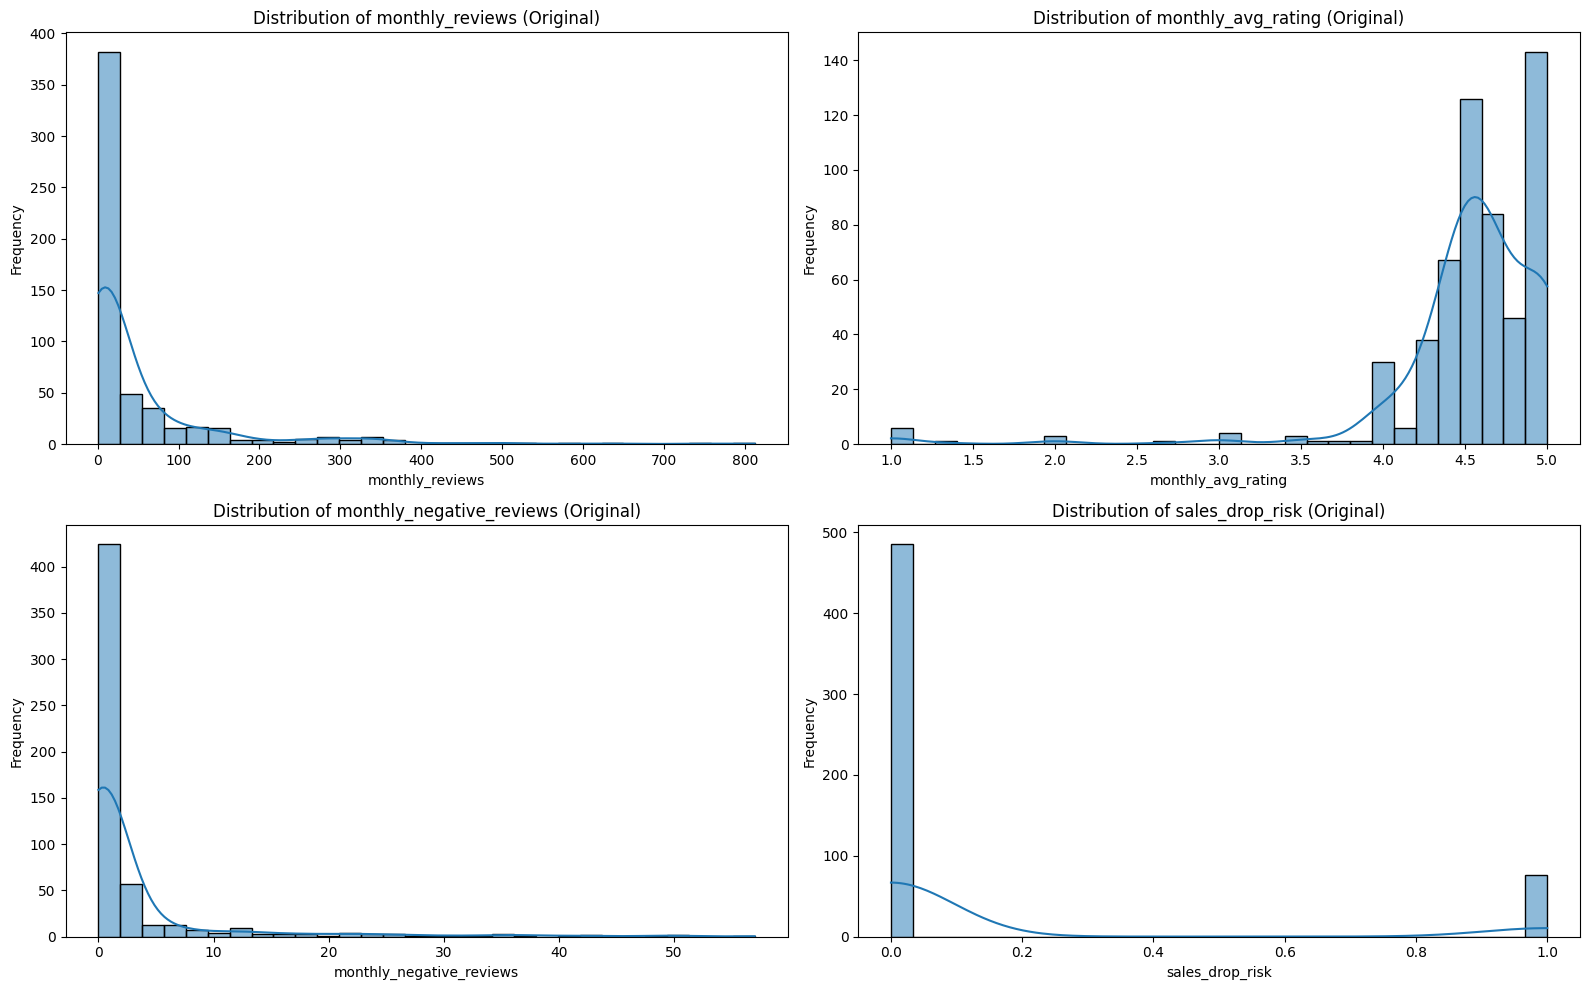

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columns to visualize (assuming these are numerical and present in both DataFrames)
plot_cols = ['monthly_reviews', 'monthly_avg_rating', 'monthly_negative_reviews', 'sales_drop_risk']

print("Histograms for final_dataset (Original Data)")
plt.figure(figsize=(16, 10))
for i, col in enumerate(plot_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(final_dataset[col], kde=True, bins=30)
    plt.title(f'Distribution of {col} (Original)')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


Histograms for final_dataset_ohe (One-Hot Encoded Data - numerical columns)


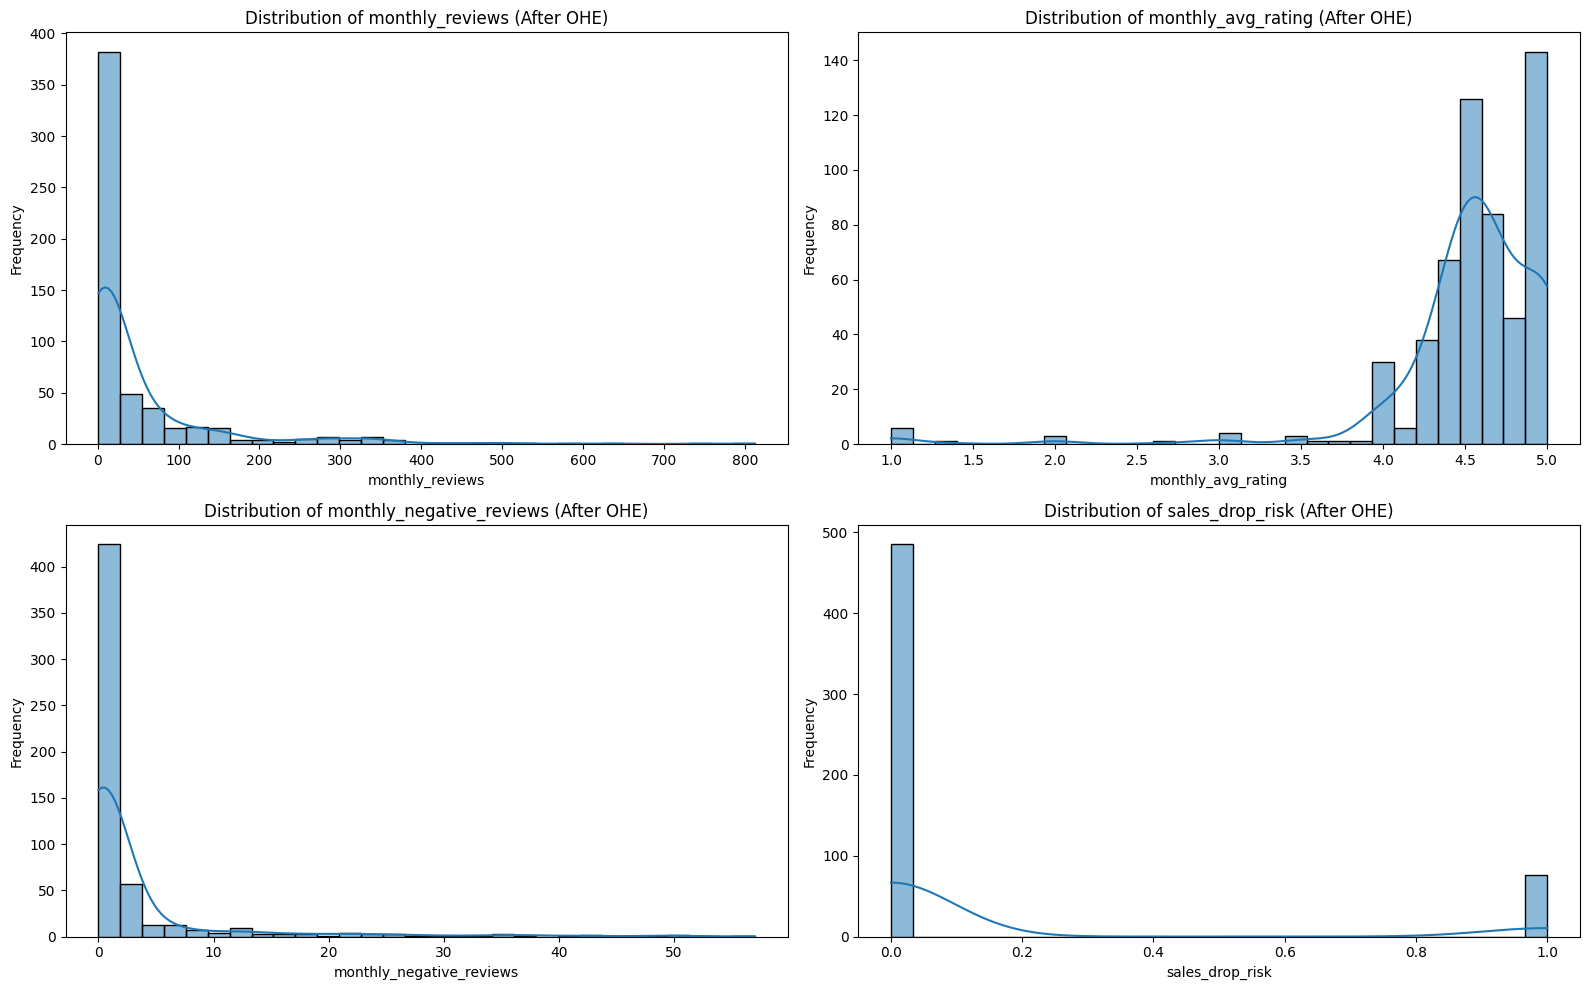

In [ ]:
print("Histograms for final_dataset_ohe (One-Hot Encoded Data - numerical columns)")
plt.figure(figsize=(16, 10))
for i, col in enumerate(plot_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(final_dataset_ohe[col], kde=True, bins=30)
    plt.title(f'Distribution of {col} (After OHE)')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


Al observar estos histogramas, notarás que las distribuciones de las variables numéricas clave (`monthly_reviews`, `monthly_avg_rating`, `monthly_negative_reviews`, `sales_drop_risk`) son idénticas en `final_dataset` y `final_dataset_ohe`. Esto es esperado, ya que la One-Hot Encoding solo afecta a las variables categóricas, creando nuevas columnas binarias sin alterar las distribuciones de las variables numéricas preexistentes.

#**Feature engineering específica del dominio**

In [ ]:
import numpy as np
import pandas as pd

# REcuerda verificar que esta cargado el dataset:
# final_dataset_ohe = pd.read_csv("final_dataset_ohe.csv")

# =========================
# 1. Evidencia antes
# =========================

print("ANTES DE CREAR LA FEATURE")
print("Shape:", final_dataset_ohe.shape)
print("Columnas existentes:")
print(final_dataset_ohe.columns.tolist())

display(
    final_dataset_ohe[
        [
            "monthly_negative_rate",
            "monthly_avg_helpful",
            "sales_drop_risk"
        ]
    ].head()
)

# =========================
# 2. Crear feature de dominio
# =========================

final_dataset_ohe["negative_helpfulness_pressure"] = (
    final_dataset_ohe["monthly_negative_rate"] *
    np.log1p(final_dataset_ohe["monthly_avg_helpful"])
)

# =========================
# 3. Crear versión binaria opcional
# =========================

# Esta variable marca los casos con presión negativa superior al percentil 75
threshold_pressure = final_dataset_ohe["negative_helpfulness_pressure"].quantile(0.75)

final_dataset_ohe["high_negative_helpfulness_pressure"] = np.where(
    final_dataset_ohe["negative_helpfulness_pressure"] > threshold_pressure,
    1,
    0
)

# =========================
# 4. Evidencia después
# =========================

print("DESPUÉS DE CREAR LA FEATURE")
print("Shape:", final_dataset_ohe.shape)

display(
    final_dataset_ohe[
        [
            "monthly_negative_rate",
            "monthly_avg_helpful",
            "negative_helpfulness_pressure",
            "high_negative_helpfulness_pressure",
            "sales_drop_risk"
        ]
    ].head(10)
)

# =========================
# 5. Estadísticas descriptivas de la nueva feature
# =========================

display(
    final_dataset_ohe[
        [
            "negative_helpfulness_pressure",
            "high_negative_helpfulness_pressure"
        ]
    ].describe()
)

# =========================
# 6. Revisar relación preliminar con el target
# =========================

display(
    final_dataset_ohe.groupby("sales_drop_risk")[
        [
            "negative_helpfulness_pressure",
            "high_negative_helpfulness_pressure"
        ]
    ].mean()
)

ANTES DE CREAR LA FEATURE
Shape: (561, 189)
Columnas existentes:
['monthly_reviews', 'monthly_avg_rating', 'monthly_negative_reviews', 'monthly_positive_reviews', 'monthly_not_recommended', 'monthly_avg_helpful', 'monthly_avg_length_words', 'monthly_negative_rate', 'monthly_positive_rate', 'monthly_not_recommended_rate', 'year_month_date', 'prev_month_avg_rating', 'prev_month_negative_rate', 'rating_change', 'negative_rate_change', 'rolling_3m_avg_rating', 'rolling_3m_negative_rate', 'total_reviews', 'avg_rating', 'min_rating', 'max_rating', 'negative_reviews', 'neutral_reviews', 'positive_reviews', 'not_recommended_count', 'avg_helpful_votes', 'total_helpful_votes', 'avg_review_length_words', 'first_review_date', 'last_review_date', 'negative_review_rate', 'positive_review_rate', 'not_recommended_rate', 'review_period_days', 'review_frequency', 'sales_drop_risk', 'year_month_date_is_null', 'prev_month_avg_rating_is_null', 'prev_month_negative_rate_is_null', 'rating_change_is_null', 'n

,monthly_negative_rate,monthly_avg_helpful,sales_drop_risk
0,0.0,44.000000,0
1,0.0,0.200000,0
2,0.0,0.222222,0
3,0.0,0.000000,0
4,0.0,0.000000,0


DESPUÉS DE CREAR LA FEATURE
Shape: (561, 191)


,monthly_negative_rate,monthly_avg_helpful,negative_helpfulness_pressure,high_negative_helpfulness_pressure,sales_drop_risk
0,0.00000,44.000000,0.0,0,0
1,0.00000,0.200000,0.0,0,0
2,0.00000,0.222222,0.0,0,0
3,0.00000,0.000000,0.0,0,0
4,0.00000,0.000000,0.0,0,0
5,0.04878,0.000000,0.0,0,0
6,0.00000,0.000000,0.0,0,0
7,0.00000,0.000000,0.0,0,0
8,0.00000,0.000000,0.0,0,1
9,0.00000,0.000000,0.0,0,0


,negative_helpfulness_pressure,high_negative_helpfulness_pressure
count,561.000000,561.000000
mean,0.059701,0.188948
std,0.485157,0.391817
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,6.432940,1.000000


,negative_helpfulness_pressure,high_negative_helpfulness_pressure
sales_drop_risk,,
0,0.002433,0.167010
1,0.425161,0.328947


In [ ]:
display(final_dataset_ohe.head())

,monthly_reviews,monthly_avg_rating,monthly_negative_reviews,monthly_positive_reviews,monthly_not_recommended,monthly_avg_helpful,monthly_avg_length_words,monthly_negative_rate,monthly_positive_rate,monthly_not_recommended_rate,...,primaryCategories_x_Home & Garden,primaryCategories_x_Office Supplies,"primaryCategories_x_Office Supplies,Electronics","primaryCategories_x_Toys & Games,Electronics",year,total_negative_reviews,total_positive_reviews,total_neutral_reviews,negative_helpfulness_pressure,high_negative_helpfulness_pressure
0,1,5.000000,0,1,0,44.000000,102.000000,0.0,1.000000,0.000000,...,0.0,0.0,0.0,0.0,2017,11430,182333,8604,0.0,0
1,5,4.600000,0,5,0,0.200000,45.400000,0.0,1.000000,0.000000,...,0.0,0.0,0.0,0.0,2017,11430,182333,8604,0.0,0
2,9,4.222222,0,8,1,0.222222,28.555556,0.0,0.888889,0.111111,...,0.0,0.0,0.0,0.0,2017,11430,182333,8604,0.0,0
3,3,4.666667,0,3,0,0.000000,21.666667,0.0,1.000000,0.000000,...,0.0,0.0,0.0,0.0,2017,11430,182333,8604,0.0,0
4,1,5.000000,0,1,0,0.000000,25.000000,0.0,1.000000,0.000000,...,0.0,0.0,0.0,0.0,2017,11430,182333,8604,0.0,0


#Selección de características

##1. Metodo Filter

In [42]:
from sklearn.feature_selection import VarianceThreshold

# Crear una NUEVA copia para no alterar final_dataset_ohe
final_dataset_ohe_filtered = final_dataset_ohe.copy()

# Seleccionar columnas numéricas para aplicar el filtro estadístico
numeric_cols = final_dataset_ohe_filtered.select_dtypes(include=["number"]).columns

# Variance Threshold: elimina variables con varianza muy baja (casi constantes)
selector = VarianceThreshold(threshold=0.01)
selector.fit(final_dataset_ohe_filtered[numeric_cols])

selected_numeric_cols = numeric_cols[selector.get_support()]
removed_numeric_cols = numeric_cols[~selector.get_support()]

print("Variables numéricas seleccionadas (VarianceThreshold):")
print(list(selected_numeric_cols))
print("Variables numéricas eliminadas (baja varianza):")
print(list(removed_numeric_cols))

# Mantener también columnas no numéricas para preservar contexto del dataset
non_numeric_cols = final_dataset_ohe_filtered.columns.difference(numeric_cols)
final_dataset_ohe_filtered = final_dataset_ohe_filtered.filter(
    items=list(non_numeric_cols) + list(selected_numeric_cols)
)

print("Dataset original (final_dataset_ohe):", final_dataset_ohe.shape)
print("Nuevo dataset filtrado (final_dataset_ohe_filtered):", final_dataset_ohe_filtered.shape)
print("Columnas removidas por baja varianza:", len(numeric_cols) - len(selected_numeric_cols))

# Vista previa del nuevo dataset
final_dataset_ohe_filtered.head()



Dataset original (final_dataset_ohe): (561, 191)
Nuevo dataset filtrado (final_dataset_ohe_filtered): (561, 119)
Columnas removidas por baja varianza: 72


,first_review_date,last_review_date,year_month_date,monthly_reviews,monthly_avg_rating,monthly_negative_reviews,monthly_positive_reviews,monthly_not_recommended,monthly_avg_helpful,monthly_avg_length_words,...,primaryCategories_x_Health & Beauty,primaryCategories_x_Office Supplies,"primaryCategories_x_Office Supplies,Electronics","primaryCategories_x_Toys & Games,Electronics",year,total_negative_reviews,total_positive_reviews,total_neutral_reviews,negative_helpfulness_pressure,high_negative_helpfulness_pressure
0,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,2017-06-01,1,5.000000,0,1,0,44.000000,102.000000,...,0.0,0.0,0.0,0.0,2017,11430,182333,8604,0.0,0
1,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,2017-07-01,5,4.600000,0,5,0,0.200000,45.400000,...,0.0,0.0,0.0,0.0,2017,11430,182333,8604,0.0,0
2,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,2017-08-01,9,4.222222,0,8,1,0.222222,28.555556,...,0.0,0.0,0.0,0.0,2017,11430,182333,8604,0.0,0
3,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,2017-09-01,3,4.666667,0,3,0,0.000000,21.666667,...,0.0,0.0,0.0,0.0,2017,11430,182333,8604,0.0,0
4,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,2017-10-01,1,5.000000,0,1,0,0.000000,25.000000,...,0.0,0.0,0.0,0.0,2017,11430,182333,8604,0.0,0
